In [36]:
import sys
!{sys.executable} -m pip install datasets
from datasets import load_dataset
import pandas as pd

# Load dataset
dataset = load_dataset("SetFit/enron_spam")

# Convert to pandas
df = pd.DataFrame(dataset['train'])

# Rename columns (cleaner)
df = df.rename(columns={
    "text": "email",
    "label": "spam"
})

# Convert labels: 1 = spam, 0 = ham
print(df.head())
print(df['spam'].value_counts())


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


Repo card metadata block was not found. Setting CardData to empty.


   message_id                                              email  spam  \
0       33214  any software just for 15 $ - 99 $ understandin...     1   
1       11929  perspective on ferc regulatory action client c...     0   
2       19784  wanted to try ci 4 lis but thought it was way ...     1   
3        2209  enron / hpl actuals for december 11 , 2000 tec...     0   
4       15880  looking for cheap high - quality software ? ro...     1   

  label_text                                            subject  \
0       spam                  any software just for 15 $ - 99 $   
1        ham  perspective on ferc regulatory action client c...   
2       spam  wanted to try ci 4 lis but thought it was way ...   
3        ham         enron / hpl actuals for december 11 , 2000   
4       spam  looking for cheap high - quality software ? ro...   

                                             message       date  
0  understanding oem software\nlead me not into t... 2005-06-18  
1  19 th , 2 : 00 pm

In [37]:
#Dataset Overview

df.info()
df.shape
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 31716 entries, 0 to 31715
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   message_id  31716 non-null  int64         
 1   email       31716 non-null  str           
 2   spam        31716 non-null  int64         
 3   label_text  31716 non-null  str           
 4   subject     31716 non-null  str           
 5   message     31716 non-null  str           
 6   date        31716 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 93.0 MB


,message_id,email,spam,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


In [38]:
#Missing Values Check

df.isnull().sum()

message_id    0
email         0
spam          0
label_text    0
subject       0
message       0
date          0
dtype: int64

In [39]:
#Class Distribution (VERY IMPORTANT for spam data)

df['label'].value_counts()

KeyError: 'label'

In [ ]:
#Text Length Analysis

df['text_length'] = df['message'].apply(len)

df['text_length'].describe()

count     31716.00000
mean       1471.82460
std        4297.32816
min           0.00000
25%         309.00000
50%         675.50000
75%        1515.00000
max      228353.00000
Name: text_length, dtype: float64

In [41]:
#Visualizations

#Class Distribution

import seaborn as sns
sns.countplot(x='label', data=df)

ValueError: Could not interpret value `label` for `x`. An entry with this name does not appear in `data`.

<Axes: xlabel='text_length', ylabel='Count'>

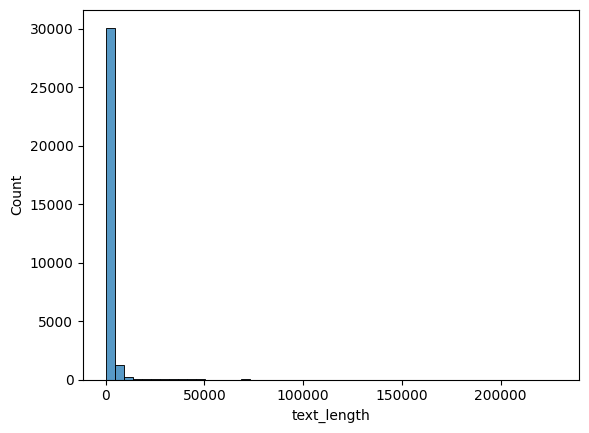

In [ ]:
#Text Length Distribution

sns.histplot(df['text_length'], bins=50)

In [ ]:
#Most Common Words
import re
from collections import Counter

# Basic Cleaning Function (moved here to resolve NameError)
def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['message'].apply(clean_text)

all_words = ' '.join(df['clean_text']).split()
common_words = Counter(all_words).most_common(20)
print(common_words)

[('the', 272454), ('to', 198834), ('and', 146717), ('of', 138803), ('a', 109823), ('in', 99755), ('for', 76195), ('you', 75561), ('is', 66922), ('_', 65059), ('this', 59658), ('enron', 55659), ('on', 54928), ('that', 53493), ('i', 52847), ('s', 48566), ('with', 44281), ('be', 44079), ('your', 42732), ('we', 40591)]


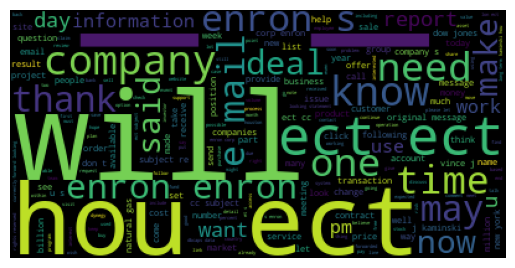

In [31]:
#WordCloud (Optional but good for presentation)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud().generate(' '.join(df['clean_text']))

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [32]:
#import required library

import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khais\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khais\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [33]:
#Basic Cleaning Function

def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [34]:
#Apply Cleaning

df['clean_text'] = df['message'].apply(clean_text)

In [35]:
#Remove Stopwords

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    return ' '.join([word for word in words if word not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [ ]:
#Tokenization (Split into words)

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
#Stemming (Optional but useful)

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['clean_text'] = df['clean_text'].apply(stemming)

In [ ]:
# Final Output Check

df[['message', 'clean_text']].head()

,message,clean_text
0,['Fabulous discounts from CanadianPharmacy. 50...,fabul discount canadianpharmaci discount produ...
1,http://houston.cowparade.net/,
2,=================================\n\nGuarantee...,guarante increas lift firm breast day money ba...
3,Thanks for your help! ---------------------- ...,thank help tana joneshouect pm conni sutton pm...
4,Start Date: 10/13/01; HourAhead hour: 23; No a...,start date hourahead hour ancillari schedul aw...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])

In [ ]:
#Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [40]:
#Initialize TF-IDF

vectorizer = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=2,            # ignore rare words
    max_df=0.8           # ignore very common words
)

NameError: name 'TfidfVectorizer' is not defined

In [ ]:
#Fit and Transform Text

X = vectorizer.fit_transform(df['clean_text'])

In [ ]:
#Check Output Shape

print(X.shape)

(6244, 5000)


In [ ]:
#Convert to DataFrame (Optional, for inspection)

tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,_____,________________________________,____________________________________,_____________________________________________,______________________________________________,______________________________________________ rhelpstatmathethzch,_______________________________________________,_______________________________________________ python,_______________________________________________ pythondev,_______________________________________________ speakup,...,young,your,youv,ze,zero,zip,zone,zoo,zvlllneumpythonorg,zvlllneumpythonorg unsubscrib
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Extract Target Variable

y = df['label']   # or 'spam', depending on your dataset

In [ ]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Train a Baseline Model (Naive Bayes)

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
#Make Predictions

y_pred = nb_model.predict(X_test)

In [ ]:
#Evaluate Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9191353082465973

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       859
           1       0.96      0.78      0.86       390

    accuracy                           0.92      1249
   macro avg       0.93      0.88      0.90      1249
weighted avg       0.92      0.92      0.92      1249


Confusion Matrix:
 [[845  14]
 [ 87 303]]


In [ ]:
#Try a Stronger Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy (LR):", accuracy_score(y_test, y_pred_lr))

Accuracy (LR): 0.9199359487590072


In [ ]:
#Try Support Vector Machine (High Accuracy)

from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))

Accuracy (SVM): 0.9287429943955164


In [ ]:
#Save the Model (Important)

import pickle

pickle.dump(lr_model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('tfidf.pkl', 'wb'))

In [ ]:
# Test with New Email

sample = ["Congratulations! You won a free lottery"]

sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

prediction = lr_model.predict(sample_vec)
print(prediction)

[0]


In [ ]:
#Basic Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))

Accuracy: 0.9191353082465973
Precision: 0.9558359621451105
Recall: 0.7769230769230769
F1 Score: 0.8571428571428571


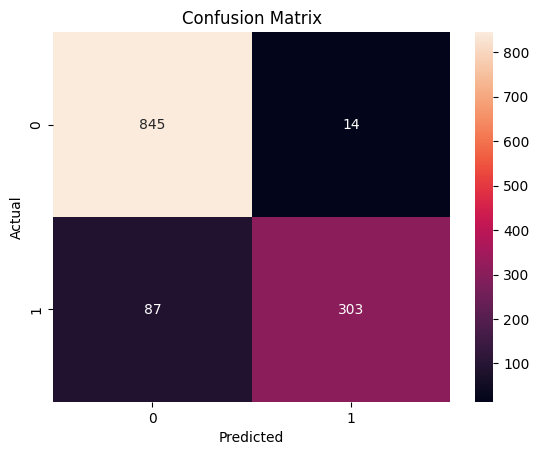

In [ ]:
#Visualize Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

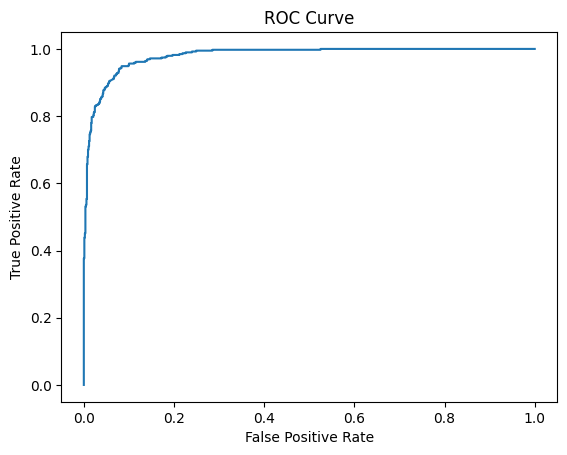

AUC Score: 0.980125966389063


In [ ]:
# ROC Curve & AUC Score (Advanced)

from sklearn.metrics import roc_curve, auc

y_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
# predict_proba()   # for NB / LR
# decision_function()  # for SVM

In [ ]:
print(y.value_counts())

label
0    4371
1    1873
Name: count, dtype: int64


In [ ]:
#Reduce Dimensions (PCA → 2D)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

In [ ]:
#Train Model on 2D Data

from sklearn.linear_model import LogisticRegression

model_2d = LogisticRegression()
model_2d.fit(X_reduced, y)

LogisticRegression()

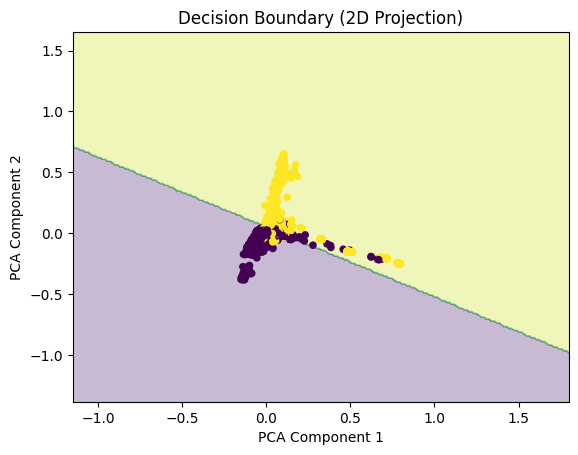

In [ ]:
#Plot Decision Boundary

import numpy as np
import matplotlib.pyplot as plt

# Create grid
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict for grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, s=20)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Decision Boundary (2D Projection)")
plt.show()

In [ ]:
#Get Most Common Words

from collections import Counter

all_words = ' '.join(df['clean_text'].dropna()).split()
common_words = Counter(all_words).most_common(20)

In [ ]:
#Separate Words & Counts

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

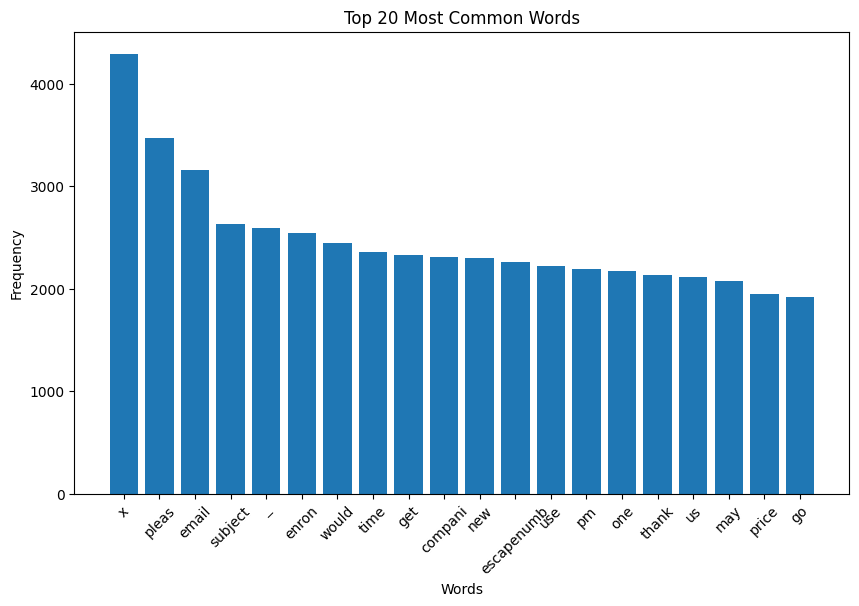

In [ ]:
#Plot Bar Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Common Words")

plt.show()